# Lecture 4 - 1D Diffusion Equation 
In this notebook, I solve the one-dimensional diffusion equation using an explicit finite-difference method

The equation is:

$$
\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial x^2}
$$

The diffusion equation describes how sharp gradients become smoother over time. In Fluid Mechanics, this is related to viscous diffusion

In [ ]:
# Importing the python libraries

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# Definition the numerical grid

nx = 41  # number of grid points
length = 2.0  # domain length

dx = length / (nx - 1)
x = np.linspace(0,length,nx) # coordinate array

print("Number of grid points", nx)
print("Domain Length: ", length)
print("Grid spacing dx:", dx)
print("First five x values:", x[:5])

Number of grid points 41
Domain Length:  2.0
Grid spacing dx: 0.05
First five x values: [0.   0.05 0.1  0.15 0.2 ]


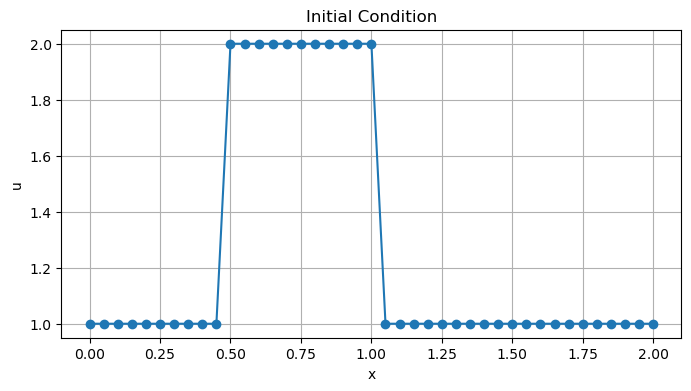

In [9]:
# Definition of the Initial Condition

u_initial = np.ones(nx)
u_initial[int(0.5 / dx):int(1.0 / dx + 1)] = 2 

plt.figure(figsize = (8,4))
plt.plot(x, u_initial, marker = "o")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Initial Condition")
plt.grid()
plt.show()

# The initial condition is: 
# u = 2 between x = 0.5 and x = 1.0
# u = 1 everywhere else 

## physical Meaning of Diffusion

Diffusion smooths gradients.

In convection, the solution is transported from one location to another.

In diffusion, high values spread into neighboring low-value regions 

For fluid mechanics, diffusion is connected to viscosity. Viscosity transfers momentum between neighboring fluid layers.

Engineering interpretation: 

- convection transports flow information
- nonlinear convection deforms the flow
- diffusion smooths gradients
- viscosity causes boundary-layer and wake effects

important idea: 

- Convection moves
- Diffusion smooths


## Finite-Difference Discretization 

The diffusion equation is: 

$$
\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial x^2}
$$

using a forward difference in time:

$$
\frac{\partial u}{\partial t}
\approx
\frac{u_i^{n+1} - u_i^n}{\Delta t}
$$

Using a central difference for the second spatial derivative: 

$$
\frac{\partial^2 u}{\partial x^2}
\approx
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}
$$

Substituting into the diffusion equation gives:

$$
u_i^{n+1}
=
u_i^n
+
\nu
\frac{\Delta t}{\Delta x^2}
\left(
u_{i+1}^n - 2u_i^n + u_{i-1}^n
\right)
$$

This is an explicit finite-difference scheme for the diffusion equation.

In [13]:
# Definition of simulation parameters

nt = 20 # number of time steps
nu = 0.3 # diffusion coefficient
sigma = 0.2 # stability parameter

dt = sigma * dx**2 / nu # time step

print("Number of time steps: ", nt)
print("Diffusion coefficient nu: ", nu)
print("Stability parameter sigma: ", sigma)
print("Time step dt:", dt)

# Important: 
# For convection: CFL = c * dt / dx
# For diffusion: sigma = nu * dt / dx^2

Number of time steps:  20
Diffusion coefficient nu:  0.3
Stability parameter sigma:  0.2
Time step dt: 0.0016666666666666672


In [21]:
# Implementation of diffusion directly

u = u_initial.copy()

for n in range(nt):
    un = u.copy()

    for i in range(1, nx-1):
        u[i] = un[i] + nu * dt / dx**2 * (un[i-1] - 2*un[i] + un[i+1])

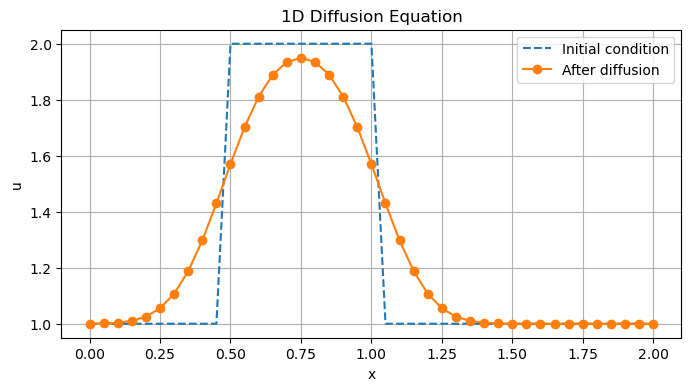

In [22]:
plt.figure(figsize = (8,4))

plt.plot(x, u_initial, label="Initial condition", linestyle="--")
plt.plot(x, u, label = "After diffusion", marker = "o")

plt.xlabel("x")
plt.ylabel("u")
plt.title("1D Diffusion Equation")
plt.legend()
plt.grid()
plt.show()

In [23]:
# Putting solver into a function

def solve_diffusion_1d(nx = 41, nt = 20, nu = 0.3, sigma = 0.2, length = 2.0):
    """
    Solve the 1D diffusion equation using an explicit finite-difference scheme.
    
    Equation:
        du/dt = nu d²u/dx²
    
    Parameters
    ----------
    nx : int
        Number of grid points.
    nt : int
        Number of time steps.
    nu : float
        Diffusion coefficient.
    sigma : float
        Stability parameter, sigma = nu * dt / dx².
    length : float
        Length of the spatial domain.
    
    Returns
    -------
    x : numpy.ndarray
        Spatial grid.
    u_initial : numpy.ndarray
        Initial condition.
    u : numpy.ndarray
        Final solution.
    dt : float
        Time-step size.
    """

    dx = length / (nx - 1)
    x = np.linspace(0, length, nx)

    dt = sigma * dx**2 / nu
    
    u_initial = np.ones(nx)
    u_initial[int(0.5 / dx):int(1.0 / dx + 1)] = 2

    u = u_initial.copy()

    for n in range(nt):
        un = u.copy()

        for i in range(1, nx - 1):
            u[i] = un[i] + nu * dt / dx**2 *(un[i+1] - 2*un[i] + un[i-1])

    return x, u_initial, u, dt


Computed time step dt: 0.0016666666666666672


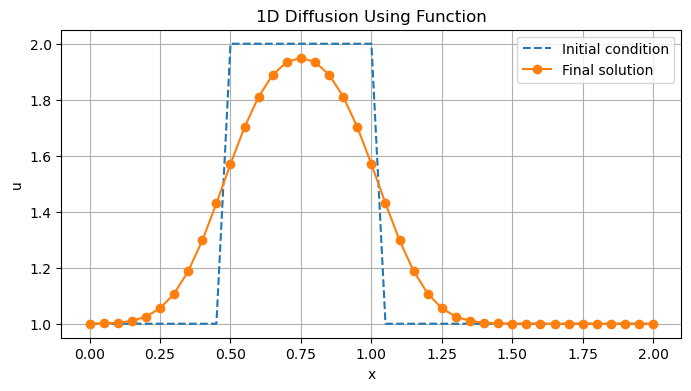

In [24]:
# Use function

x, u_initial, u_final, dt = solve_diffusion_1d(
    nx=41,
    nt=20,
    nu=0.3,
    sigma=0.2,
    length=2.0
)

print("Computed time step dt:", dt)

plt.figure(figsize=(8, 4))
plt.plot(x, u_initial, label="Initial condition", linestyle="--")
plt.plot(x, u_final, label="Final solution", marker="o")
plt.xlabel("x")
plt.ylabel("u")
plt.title("1D Diffusion Using Function")
plt.legend()
plt.grid()
plt.show()

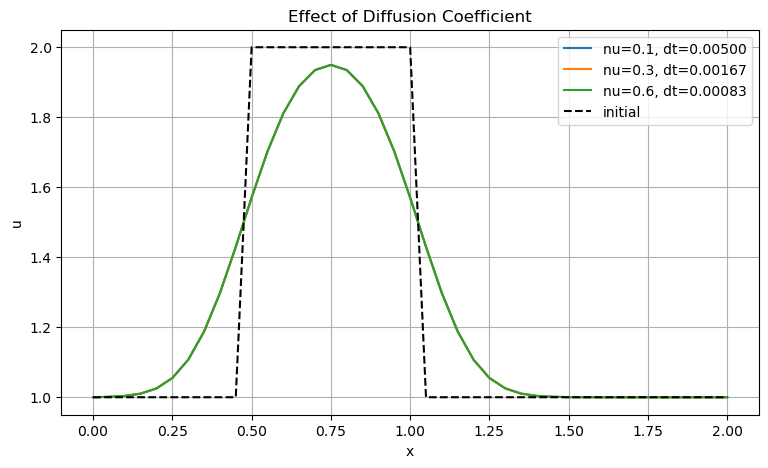

In [28]:
# Study the effect of diffusion coefficient 

nu_values = [0.1, 0.3, 0.6]

plt.figure(figsize=(9,5))

for nu_test in nu_values:
    x, u_initial, u_result, dt = solve_diffusion_1d(nx = 41, nt = 20, nu = nu_test, sigma=0.2, length = 2.0)

    plt.plot(x, u_result, label=f"nu={nu_test}, dt={dt:.5f}")

plt.plot(x, u_initial, "k--", label = "initial")

plt.xlabel("x")
plt.ylabel("u")
plt.title("Effect of Diffusion Coefficient")
plt.legend()
plt.grid()
plt.show()

# Larger diffusion coeffiecient means stronger smoothing 
# Smaller diffusion coeffiecient means weaker smoothing

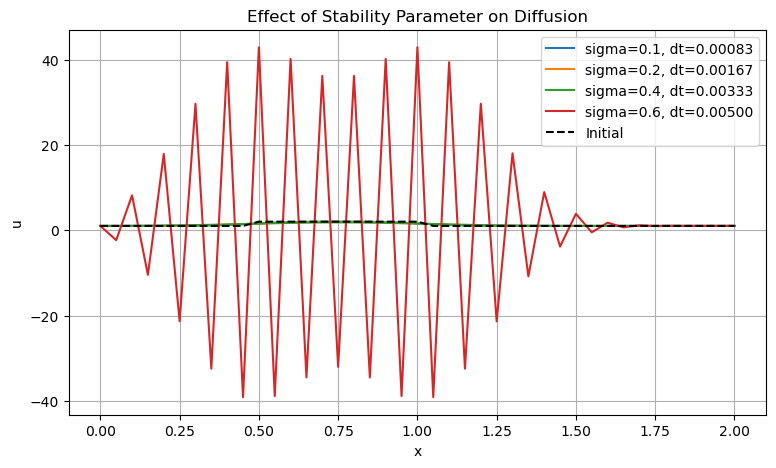

In [33]:
sigma_values = [0.1, 0.2, 0.4, 0.6]

plt.figure(figsize=(9, 5))

for sigma_test in sigma_values:
    x, u_initial, u_result, dt = solve_diffusion_1d(
        nx=41,
        nt=20,
        nu=0.3,
        sigma=sigma_test,
        length=2.0
    )
    
    plt.plot(x, u_result, label=f"sigma={sigma_test}, dt={dt:.5f}")

plt.plot(x, u_initial, "k--", label="Initial")

plt.xlabel("x")
plt.ylabel("u")
plt.title("Effect of Stability Parameter on Diffusion")
plt.legend()
plt.grid()
plt.show()

# Expected result: 
# signma <= 0.5 -> generally stable
# signma > 0.5 -> may become unstable

# For sigma = 0.6, the result may show nonphysical oscillations or instability.

When sigma exceeds the stability limit, the explicit diffusion scheme becomes unstable. The time step is too large relative to the grid spacing and diffusion coefficient.

## Python Concept: Vectorized Update

The Loop version updates one grid point at a time

The vectorized version updates all interior grid points at once using Numpy slicing.

For a 1D array: 

- `[1:-1]` means all interior points
- `u[2:]` means right neighbors
- `u[:-2]` means left neighbors

Vectorization is important in scientific Python because it is usually faster and cleaner than pure Python loops

In [34]:
def solve_diffusion_1d_vectorized(nx=41, nt=20, nu=0.3, sigma=0.2, length=2.0):
    """
    Solve the 1D diffusion equation using a vectorized NumPy update.
    """
    
    dx = length / (nx - 1)
    x = np.linspace(0, length, nx)
    
    dt = sigma * dx**2 / nu
    
    u_initial = np.ones(nx)
    u_initial[int(0.5 / dx):int(1.0 / dx + 1)] = 2
    
    u = u_initial.copy()
    
    for n in range(nt):
        un = u.copy()
        
        u[1:-1] = un[1:-1] + nu * dt / dx**2 * (
            un[2:] - 2*un[1:-1] + un[:-2]
        )
    
    return x, u_initial, u, dt

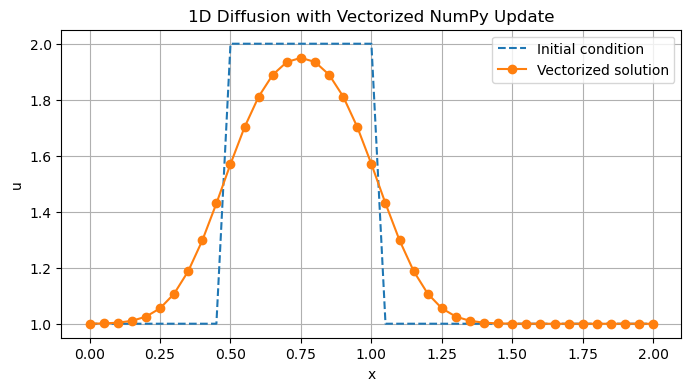

In [35]:
x, u_initial, u_vectorized, dt = solve_diffusion_1d_vectorized(
    nx=41,
    nt=20,
    nu=0.3,
    sigma=0.2
)

plt.figure(figsize=(8, 4))
plt.plot(x, u_initial, label="Initial condition", linestyle="--")
plt.plot(x, u_vectorized, label="Vectorized solution", marker="o")
plt.xlabel("x")
plt.ylabel("u")
plt.title("1D Diffusion with Vectorized NumPy Update")
plt.legend()
plt.grid()
plt.show()

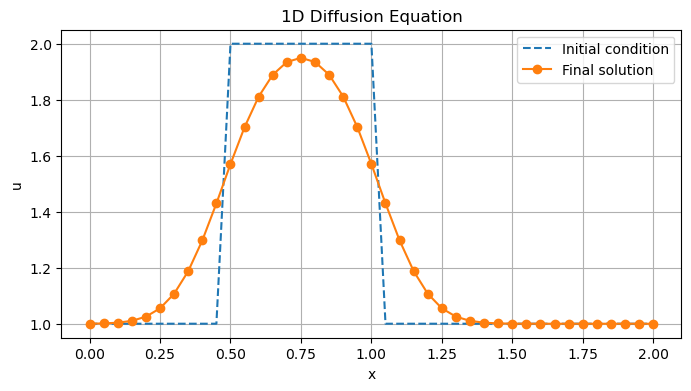

In [36]:
x, u_initial, u_final, dt = solve_diffusion_1d(
    nx=41,
    nt=20,
    nu=0.3,
    sigma=0.2,
    length=2.0
)

fig_dir = Path("../figures")

if not fig_dir.exists():
    fig_dir = Path("figures")

fig_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8, 4))
plt.plot(x, u_initial, label="Initial condition", linestyle="--")
plt.plot(x, u_final, label="Final solution", marker="o")
plt.xlabel("x")
plt.ylabel("u")
plt.title("1D Diffusion Equation")
plt.legend()
plt.grid()

plt.savefig(fig_dir / "04_diffusion_1d.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

In this notebook, I solved the one-dimensional diffusion equation:

$$
\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial x^2}
$$

Main concepts learned: 

- diffusion equation 
- viscosity-like smoothing
- second spatial derivative
- central finite-difference approximation 
- explicit time marching 
- diffusion stability parameter
- effect of diffusion coefficient 
- effect of time-step size 
- Numpy slicing and vectorized updates

Engineering interpretation:

Diffusion smooths sharp gradients in the solution. In fluid mechanics, this is related to viscosity, which transfers momentum between neighboring fluid layers.
In aerospace and automotive aerodynamics, viscous diffusion is important for boundary layers, skin-friction drag, wake dissipation, diffuser losses, and flow separation behaviour.

## The most important update equation is: 
 u[i] = un[i] + nu * dt / dx**2 * (un[i+1] - 2*un[i] + un[i-1])

The new value at point i depends on: 
- the old value at point i
- the left neighbor
- the right neighbor
- the diffusion coefficient

Diffusion uses information from both sides
Convection with positive speed used mostly the upstream side 
un[i] - un[i-1]

Diffusion uses curvature: 
un[i+1] - 2*un[i] + un[i-1]

That curvature tells the solver where the solution should smooth. 

# For Aerodynamics

Convection:
Flow structures are transported downstream.

Nonlinear Convection:
Flow structures deform and interact.

Diffusion: 
Viscosity smooths velocity gradients and dissipates flow structures. 

# Examples 

F1 rear wing wake: 
Vortices convect downstream, deform and gradually dissipate.

Aircraft boundary layer: 
Velocity changes from zero at the wall to freestream velocity away from the wall because of viscosity.

Diffuser flow: 
Strong adverse pressure gradients and viscous effects can cause seperation and losses. 

Wing Tip vortex:
The vortex is transported downstream, but viscous diffusion gradually weakens it.



